# Comprehensive OpenCV Assignment

Follow the instructions in each section and write your code in the provided empty cells using the specified file names.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Reading Images and Videos
**Task:**
1. Read the image `cats.jpg` and display it.
2. Read the video `dog.mp4` and display it frame by frame. Ensure the video window closes when the 'd' key is pressed.

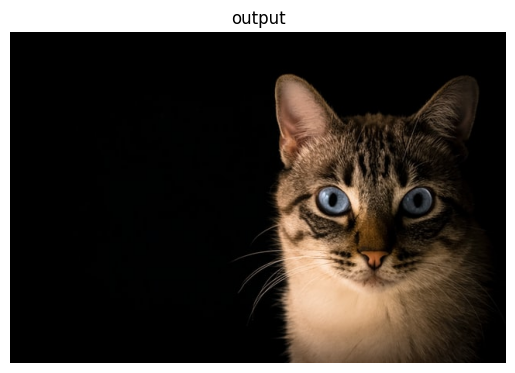

In [5]:
# Write your code here
!pip install opencv-python

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


def imshow(title = "", image = None):
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(title)
    plt.show()

cat=cv.imread('/content/cat.jpg')
imshow('output',cat)


## 2. Drawing and Text
**Task:**
1. Create a blank image of size $500 \times 500$ with 3 color channels.
2. Paint a portion of the image red ($[200:300, 300:400]$).
3. Draw a green rectangle from $(0,0)$ to the center of the image.
4. Draw a red circle at the center with a radius of 40.
5. Draw a white line from $(100, 250)$ to $(300, 400)$.



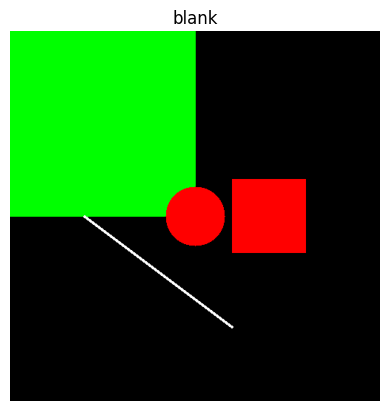

In [6]:
# Write your code here

blank=np.zeros((500,500,3),dtype='uint8')
# blank[:,:,:]=255
blank[200:300,300:400,2]=255
cv.rectangle(blank,(0,0),(250,250),(0,255,0),-1)
cv.circle(blank,(250,250),40,(0,0,255),-1)
cv.line(blank,(100,250),(300,400),(255,255,255),2)
imshow('blank',blank)


## 3. Basic Image Functions
**Task:**
1. Load `park.jpg`.
2. Convert it to grayscale.
3. Apply Gaussian Blur with a $(7,7)$ kernel.
4. Perform Canny Edge detection on the blurred image.


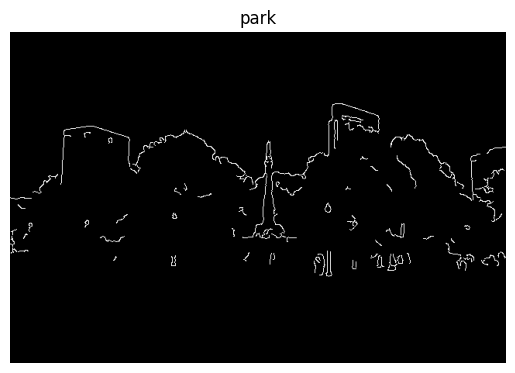

In [7]:
# Write your code here
park=cv.imread('park.jpg')
park_gray=cv.cvtColor(park,cv.COLOR_BGR2GRAY)
park_gray_blur=cv.GaussianBlur(park_gray,(7,7),0)
canny=cv.Canny(park_gray_blur,100,180)
imshow('park',canny)

## 4. Image Transformations
**Task:**
1. Create a function `translate(img, x, y)` to shift an image.
2. Create a function `rotate(img, angle, rotPoint=None)` to rotate an image.
3. Apply a flip transformation to `park.jpg`.

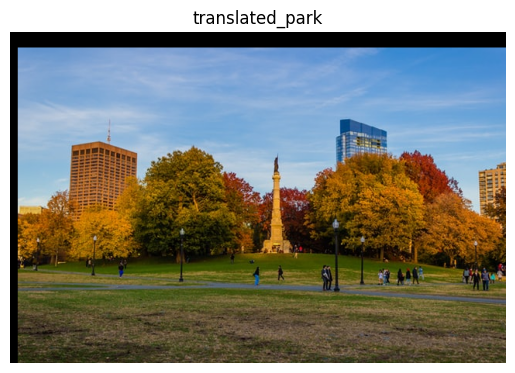

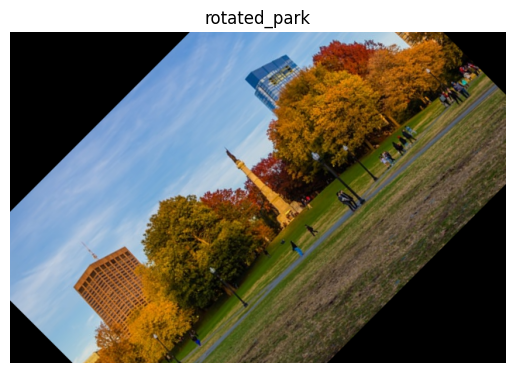

In [8]:
# Write your code here

def translate(image,x,y):
    translation_matrix=np.float64([[1,0,x],[0,1,y]])
    return cv.warpAffine(image,translation_matrix,(image.shape[1],image.shape[0]))
def rotate(img, angle, rotPoint=None):
    h, w = img.shape[:2]
    if rotPoint is None:
        rotPoint = (w//2, h//2)
    rotation_matrix=cv.getRotationMatrix2D(rotPoint,angle,1)
    return cv.warpAffine(img,rotation_matrix,(w,h))

translated_img=translate(park,10,20)
imshow('translated_park',translated_img)
rotated_img=rotate(park,45)
imshow('rotated_park',rotated_img)

## 5. Contour Detection
**Task:**
1. Load `cats.jpg`.
2. Convert to grayscale and apply Gaussian blur.
3. Find the edges using Canny.
4. Use `cv.findContours` to find all contours.
5. Print the count and draw them on a blank image.

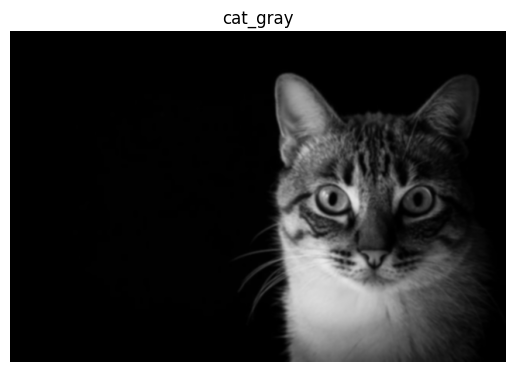

101 number of contours


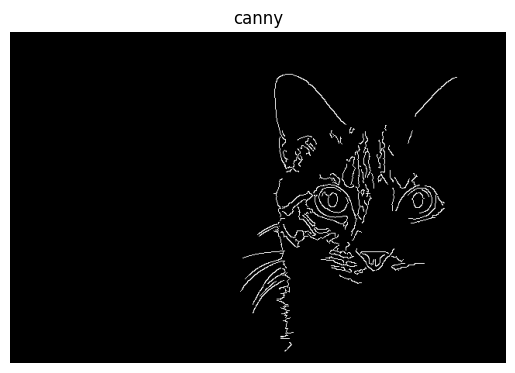

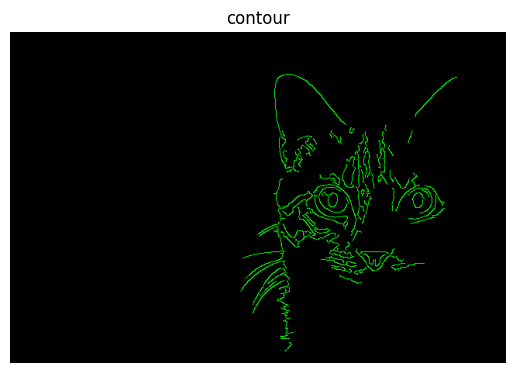

In [17]:
# Write your code here
cat_gray=cv.cvtColor(cat,cv.COLOR_BGR2GRAY)
cat_gray_blur=cv.GaussianBlur(cat_gray,(5,5),0)


imshow('cat_gray',cat_gray_blur)
cat_canny=cv.Canny(cat_gray_blur,90,190)

contours, hierarchy = cv.findContours(cat_canny,cv.RETR_LIST,cv.CHAIN_APPROX_NONE)
blank_cat = np.zeros(cat.shape, dtype=np.uint8)
cv.drawContours(blank_cat, contours, -1, (0,255,0), 1)
print(f'{len(contours)} number of contours')
imshow('canny',cat_canny)
imshow('contour',blank_cat)

## 6. Color Spaces
**Task:**
1. Load `park.jpg`.
2. Convert and display in: Gray, HSV,and RGB.

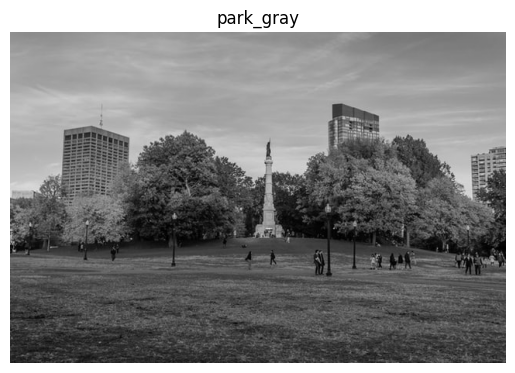

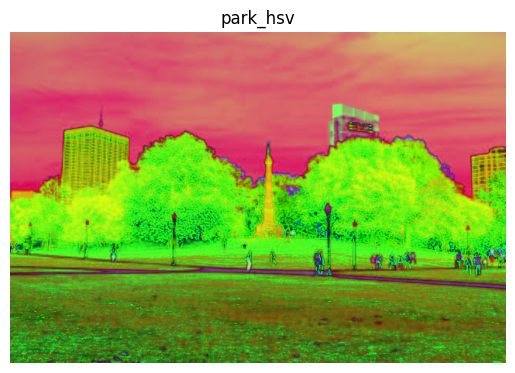

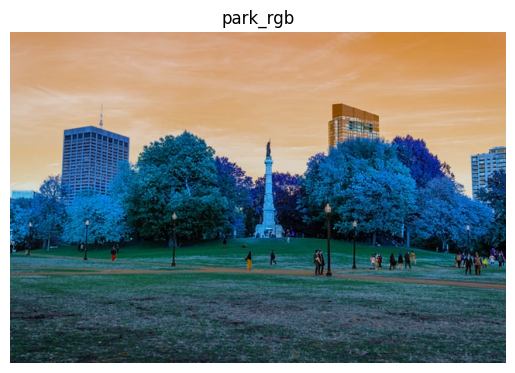

In [23]:
# Write your code here
imshow('park_gray',park_gray)
park_hsv=cv.cvtColor(park,cv.COLOR_BGR2HSV)
imshow('park_hsv',park_hsv)
park_rgb=cv.cvtColor(park,cv.COLOR_BGR2RGB)
imshow('park_rgb',park_rgb)

## 7. Smoothing and Blurring
**Task:**
1. Load `cats.jpg`.
2. Apply Averaging, Gaussian and Median Blurs

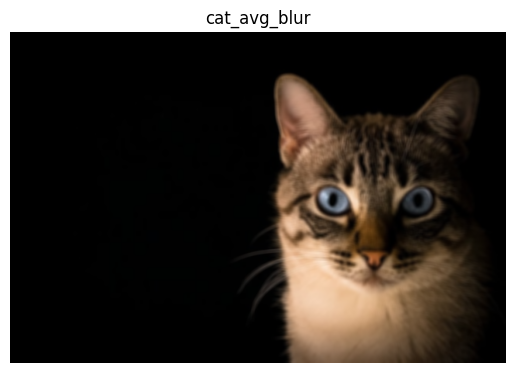

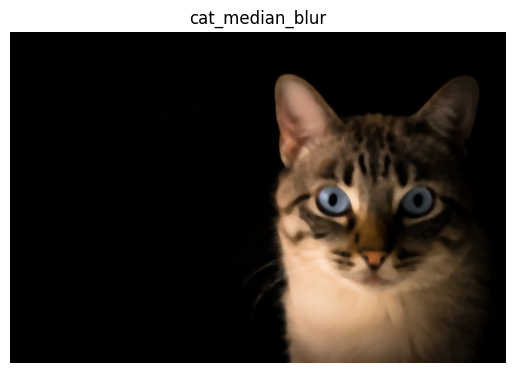

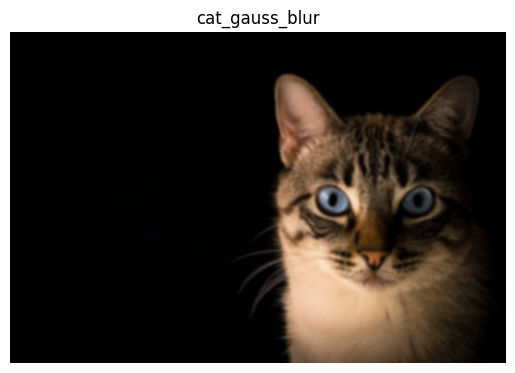

In [28]:
# Write your code here
cat_avg_blur=cv.blur(cat,(5,5))
imshow('cat_avg_blur',cat_avg_blur)
cat_median_blur=cv.medianBlur(cat,7)
imshow('cat_median_blur',cat_median_blur)
cat_gauss_blur=cv.GaussianBlur(cat,(7,7),0)
imshow('cat_gauss_blur',cat_gauss_blur)

## 8. Bitwise Operations
**Task:**
1. Create a $400 \times 400$ blank image.
2. Create a rectangle and a circle on separate blank images.
3. Perform Bitwise AND, OR, XOR, and NOT.

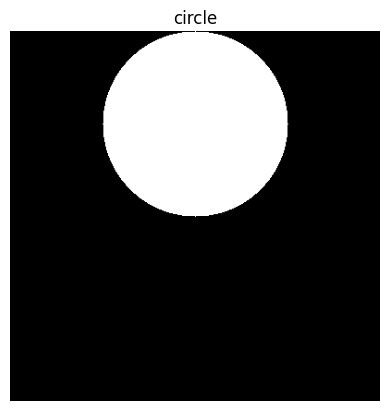

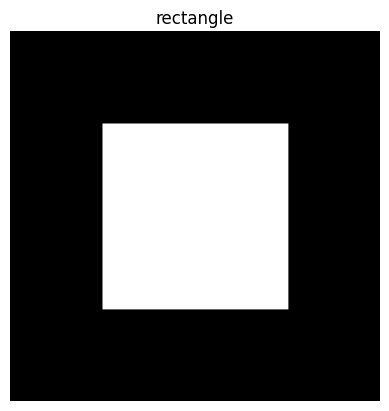

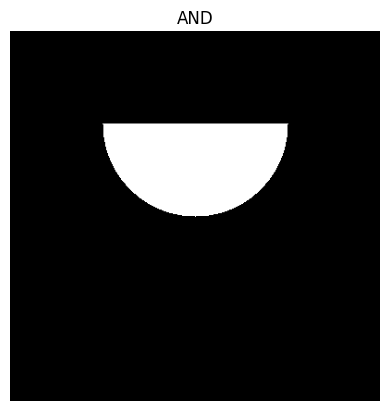

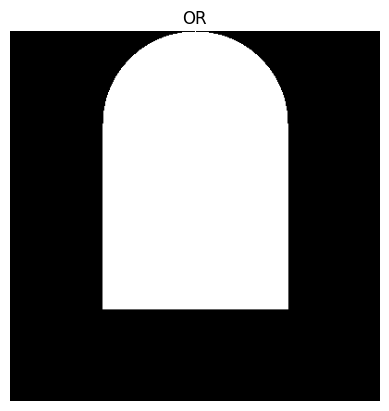

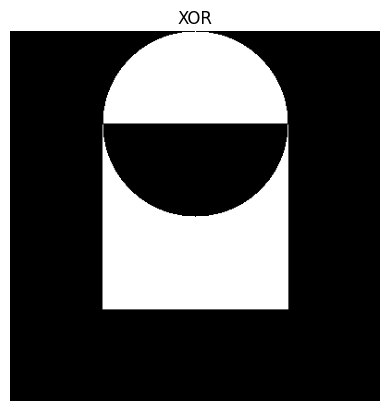

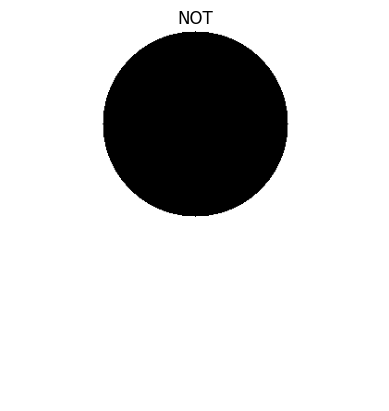

In [32]:
# Write your code here
rect=np.zeros((400,400),dtype='uint8')
circle=np.zeros((400,400),dtype='uint8')
cv.rectangle(rect,(100,100),(300,300),(255,255,255),-1)
cv.circle(circle,(200,100),100,(255,255,255),-1)

imshow('circle',circle)
imshow('rectangle',rect)
bit_and=cv.bitwise_and(circle,rect)
bit_or=cv.bitwise_or(circle,rect)
bit_xor=cv.bitwise_xor(circle,rect)
bit_not=cv.bitwise_not(circle)

imshow('AND',bit_and)
imshow('OR',bit_or)
imshow('XOR',bit_xor)
imshow('NOT',bit_not)


## 9. Thresholding
**Task:**
1. Load `cats.jpg` and convert to grayscale.
2. Apply Simple Thresholding (Binary and Inverse).

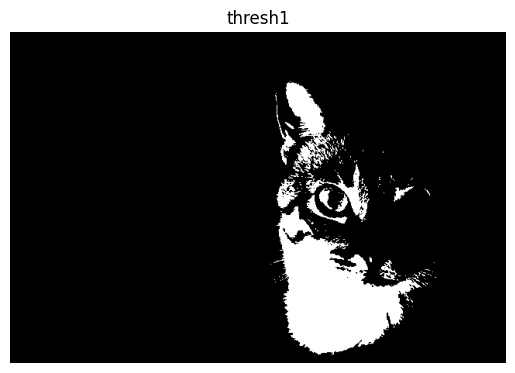

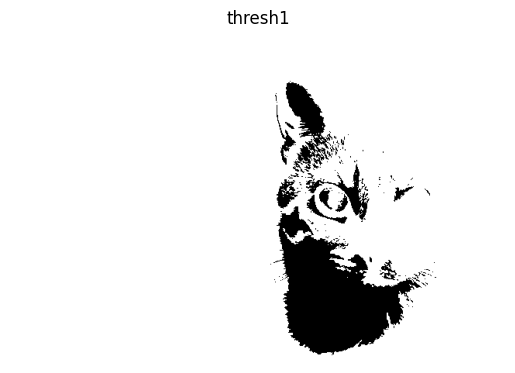

In [35]:
# Write your code here
ret, thresh_1=cv.threshold(cat_gray,120,255,cv.THRESH_BINARY)
imshow('thresh1',thresh_1)

ret, thresh_2=cv.threshold(cat_gray,120,255,cv.THRESH_BINARY_INV)
imshow('thresh1',thresh_2)